Imports

In [7]:
!pip install networkx
!pip install pennylane


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [8]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

# Import the core logic from your unified engine
from l_vqe_engine import (
    build_k_community_hamiltonian,
    best_known_community_cost,
    simulate_one_lvqe,
    total_qubits
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


=== 1. GRAPH SETUP & BASELINE ===


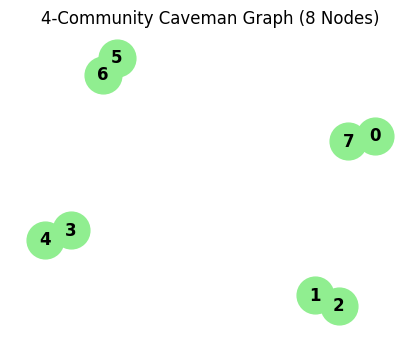

Calculating exact classical baseline...
True Maximum Modularity (C_bkv): 0.750000
Total Qubits Required: 16


In [9]:
print("=== 1. GRAPH SETUP & BASELINE ===")

# Generate the 8-node (4 communities of 2 nodes) Caveman Graph
G_test = nx.connected_caveman_graph(l=4, k=2)
k_target = 4
n_nodes = G_test.number_of_nodes()
n_qubits = total_qubits(n_nodes, k_target)

# Visualize the graph
plt.figure(figsize=(4, 3))
nx.draw(G_test,  with_labels=True, 
    node_color='lightgreen', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=700)
plt.title(f"4-Community Caveman Graph ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline using the exact modularity math
print("Calculating exact classical baseline...")
true_baseline = best_known_community_cost(G_test, k=k_target)
print(f"True Maximum Modularity (C_bkv): {true_baseline:.6f}")
print(f"Total Qubits Required: {n_qubits}")

In [10]:
print("\n=== 2. L-VQE (COBYLA) EXECUTION ===")

# Build the exact qubit-frugal Hamiltonian
H_comm = build_k_community_hamiltonian(G_test, k_target)

# Run L-VQE with COBYLA
rng_cobyla = np.random.default_rng(42)
cobyla_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,               # Statevector simulation
    max_iter_per_layer=600,   # Gives the 3,000 total budget
    rng=rng_cobyla,
    optimizer="COBYLA",
    device_name="lightning.qubit"
)

# Remember: VQE minimizes cost (negative modularity), so we flip the sign
cobyla_modularity = -cobyla_results['final_cost']
cobyla_rho = cobyla_modularity / true_baseline

print(f"\nCOBYLA Final Modularity: {cobyla_modularity:.6f}")
print(f"COBYLA Approximation Ratio (ρ): {cobyla_rho:.4f}")


=== 2. L-VQE (COBYLA) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.750000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000

COBYLA Final Modularity: 0.750000
COBYLA Approximation Ratio (ρ): 1.0000


In [4]:
print("\n=== 3. L-VQE (SMO) EXECUTION ===")

# We use the exact same random seed so both optimizers start on the exact same point on the mountain
rng_smo = np.random.default_rng(42) 

smo_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_smo,
    optimizer="SMO",
    device_name="lightning.qubit"
)

smo_modularity = -smo_results['final_cost']
smo_rho = smo_modularity / true_baseline

print(f"\nSMO Final Modularity: {smo_modularity:.6f}")
print(f"SMO Approximation Ratio (ρ): {smo_rho:.4f}")


=== 3. L-VQE (SMO) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000

SMO Final Modularity: 0.750000
SMO Approximation Ratio (ρ): 1.0000



=== 4. OPTIMIZER TRAJECTORY COMPARISON ===


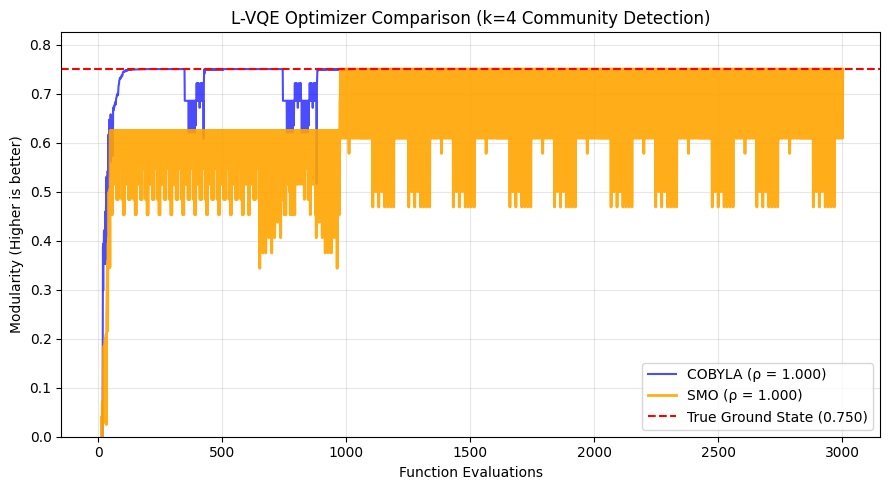

In [5]:
print("\n=== 4. OPTIMIZER TRAJECTORY COMPARISON ===")
plt.figure(figsize=(9, 5))

# Convert VQE costs back to positive modularity for the plot
plt.plot([-c for c in cobyla_results["cost_history"]], label=f"COBYLA (ρ = {cobyla_rho:.3f})", color='blue', alpha=0.7)
plt.plot([-c for c in smo_results["cost_history"]], label=f"SMO (ρ = {smo_rho:.3f})", color='orange', alpha=0.9, linewidth=2)

# Plot the absolute classical ceiling
plt.axhline(true_baseline, color="red", linestyle="--", linewidth=1.5, label=f"True Ground State ({true_baseline:.3f})")

plt.title("L-VQE Optimizer Comparison (k=4 Community Detection)")
plt.xlabel("Function Evaluations")
plt.ylabel("Modularity (Higher is better)")
plt.ylim(0, true_baseline * 1.1)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== 1. GRAPH SETUP & BASELINE (Ring of Cliques) ===


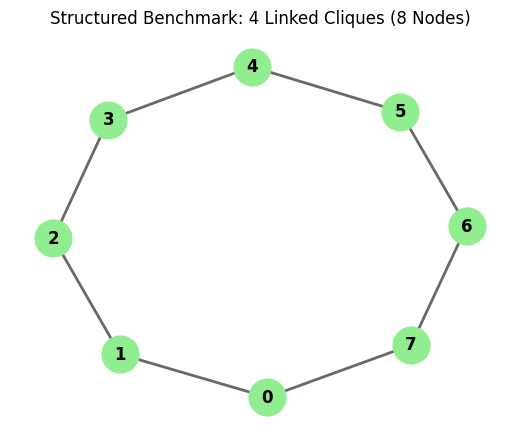

Calculating exact classical baseline...
True Maximum Modularity (C_bkv): 0.281250
Total Qubits Required: 16


In [6]:
print("=== 1. GRAPH SETUP & BASELINE (Ring of Cliques) ===")

# Generate a highly structured graph: 4 distinct cliques, connected in a ring.
# 4 cliques * 2 nodes each = 8 nodes total. 
# This guarantees a perfect, high-fidelity 4-community landscape.
G_simple = nx.ring_of_cliques(num_cliques=4, clique_size=2)
k_target = 4
n_nodes = G_simple.number_of_nodes()
n_qubits = total_qubits(n_nodes, k_target)

# VISUALIZATION
plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G_simple, seed=42) 
nx.draw(
    G_simple, 
    pos, 
    with_labels=True, 
    node_color='lightgreen', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=700
)
plt.title(f"Structured Benchmark: 4 Linked Cliques ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline
print("Calculating exact classical baseline...")
true_baseline = best_known_community_cost(G_simple, k=k_target)
print(f"True Maximum Modularity (C_bkv): {true_baseline:.6f}")
print(f"Total Qubits Required: {n_qubits}")

In [ ]:
# print("\n=== 2. L-VQE (COBYLA) EXECUTION ===")

# # Build the exact qubit-frugal Hamiltonian
# H_comm = build_k_community_hamiltonian(G_simple, k_target)

# # Run L-VQE with COBYLA
# rng_cobyla = np.random.default_rng(42)
# cobyla_results = simulate_one_lvqe(
#     n_q=n_qubits,
#     H=H_comm,
#     max_layers=2,
#     shots=None,               # Statevector simulation
#     max_iter_per_layer=600,   # Gives the 3,000 total budget
#     rng=rng_cobyla,
#     optimizer="COBYLA",
#     device_name="lightning.qubit"
# )

# # Remember: VQE minimizes cost (negative modularity), so we flip the sign
# cobyla_modularity = -cobyla_results['final_cost']
# cobyla_rho = cobyla_modularity / true_baseline

# print(f"\nCOBYLA Final Modularity: {cobyla_modularity:.6f}")
# print(f"COBYLA Approximation Ratio (ρ): {cobyla_rho:.4f}")


=== 2. L-VQE (COBYLA) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.281246
  Layer 1  (76 params) ... cost = -0.281249
  Layer 2  (136 params) ... 

KeyboardInterrupt: 

In [ ]:
print("\n=== 3. L-VQE (SMO) EXECUTION ===")

# We use the exact same random seed so both optimizers start on the exact same point on the mountain
rng_smo = np.random.default_rng(42) 

smo_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_smo,
    optimizer="SMO",
    device_name="lightning.qubit"
)

smo_modularity = -smo_results['final_cost']
smo_rho = smo_modularity / true_baseline

print(f"\nSMO Final Modularity: {smo_modularity:.6f}")
print(f"SMO Approximation Ratio (ρ): {smo_rho:.4f}")


=== 3. L-VQE (SMO) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.250000
  Layer 1  (76 params) ... cost = -0.281250
  Layer 2  (136 params) ... cost = -0.281250

SMO Final Modularity: 0.281250
SMO Approximation Ratio (ρ): 1.0000



=== 4. OPTIMIZER TRAJECTORY COMPARISON ===


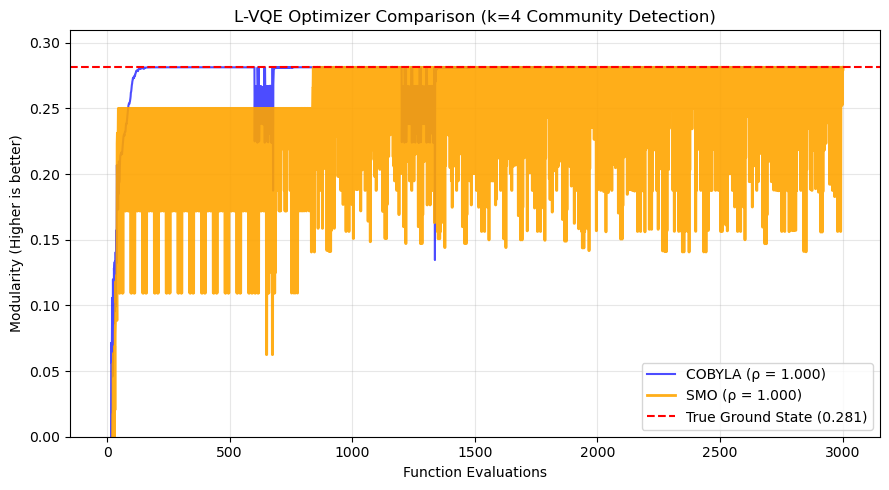

In [ ]:
print("\n=== 4. OPTIMIZER TRAJECTORY COMPARISON ===")
plt.figure(figsize=(9, 5))

# Convert VQE costs back to positive modularity for the plot
plt.plot([-c for c in cobyla_results["cost_history"]], label=f"COBYLA (ρ = {cobyla_rho:.3f})", color='blue', alpha=0.7)
plt.plot([-c for c in smo_results["cost_history"]], label=f"SMO (ρ = {smo_rho:.3f})", color='orange', alpha=0.9, linewidth=2)

# Plot the absolute classical ceiling
plt.axhline(true_baseline, color="red", linestyle="--", linewidth=1.5, label=f"True Ground State ({true_baseline:.3f})")

plt.title("L-VQE Optimizer Comparison (k=4 Community Detection)")
plt.xlabel("Function Evaluations")
plt.ylabel("Modularity (Higher is better)")
plt.ylim(0, true_baseline * 1.1)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### L-VQE vs QAOA

In [ ]:
# import time
# import pandas as pd
# import numpy as np
# import networkx as nx
# import pennylane as qml
# from pennylane import numpy as pnp # Precautionary as requested

# # Import from your engine
# from l_vqe_engine import (
#     build_k_community_hamiltonian,
#     best_known_community_cost,
#     simulate_one_lvqe,
#     simulate_one_qaoa,
#     total_qubits
# )

# print("=== STARTING MASSIVE BATCH ANALYSIS ===")

# # --- Configuration ---
# graph_sizes = [7, 8, 9, 10]
# n_seeds = 10
# k_target = 4
# device = "lightning.qubit"  # Fast statevector backend

# # Budgets
# lvqe_evals_per_layer = 600  # Yields 3,000 total (600 + 600 + 1800)
# qaoa_evals = 3000           # Gives QAOA the exact same 3,000 budget per run
# qaoa_p_values = list(range(1, 11)) # p = 1 to 10

# # Master data collection list
# results_data = []

# for n_nodes in graph_sizes:
#     print(f"\n--- Processing Graph: {n_nodes} Nodes ---")
    
#     # 1. Generate the exact topology used in the paper
#     G = nx.erdos_renyi_graph(n_nodes, p=0.5, seed=42)
#     n_q = total_qubits(n_nodes, k_target)
    
#     print(f"Calculating true baseline for {n_nodes} nodes...")
#     true_baseline = best_known_community_cost(G, k=k_target)
#     print('True Baseline:',true_baseline)
#     H_comm = build_k_community_hamiltonian(G, k_target)
    
#     for seed in range(n_seeds):
#         print(f"  Running Seed {seed+1}/{n_seeds}...")
#         rng = np.random.default_rng(seed)
        
#         # --- A. L-VQE (SMO) ---
#         print('L-VQE(SMO):')
#         t0 = time.time()
#         res_smo = simulate_one_lvqe(
#             n_q, H_comm, max_layers=2, shots=None, 
#             max_iter_per_layer=lvqe_evals_per_layer, 
#             rng=rng, device_name=device, optimizer="SMO"
#         )
#         rho_smo = -res_smo['final_cost'] / true_baseline
#         entry = {"Algorithm": "L-VQE (SMO)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_smo, "Time_s": time.time()-t0}
#         results_data.append(entry)
#         #print(entry)

#         # --- B. L-VQE (COBYLA) ---
#         print('L-VQE(COBYLA):')
#         t0 = time.time()
#         res_cobyla = simulate_one_lvqe(
#             n_q, H_comm, max_layers=2, shots=None, 
#             max_iter_per_layer=lvqe_evals_per_layer, 
#             rng=rng, device_name=device, optimizer="COBYLA"
#         )
#         rho_cobyla = -res_cobyla['final_cost'] / true_baseline
#         entry = {"Algorithm": "L-VQE (COBYLA)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_cobyla, "Time_s": time.time()-t0}
#         results_data.append(entry)
#         #print(entry)

#         #--- C. QAOA (p = 1 to 10) ---
#         print('QAOA:')
#         for p in qaoa_p_values:
#             print("p =",p)
#             t0 = time.time()
#             res_qaoa = simulate_one_qaoa(
#                 n_q, H_comm, p_steps=p, shots=None, 
#                 max_evals=qaoa_evals, rng=rng, device_name=device
#             )
#             rho_qaoa = -res_qaoa['final_cost'] / true_baseline
#             results_data.append({"Algorithm": "QAOA", "Nodes": n_nodes, "Seed": seed, "p_or_L": p, "Rho": rho_qaoa, "Time_s": time.time()-t0})

# # --- Compile and Export ---
# print("\n=== ANALYSIS COMPLETE. COMPILING DATA ===")
# df_results = pd.DataFrame(results_data)
# csv_filename = "data_community_benchmark.csv"
# df_results.to_csv(csv_filename, index=False)
# print(f"Data successfully exported to '{csv_filename}'.")

# # Display a quick preview of the average performance
# display(df_results.groupby(['Algorithm', 'Nodes', 'p_or_L'])['Rho'].mean().unstack(level=0))

=== STARTING MASSIVE BATCH ANALYSIS ===

--- Processing Graph: 7 Nodes ---
Calculating true baseline for 7 nodes...
True Baseline: 0.13223140495867766
  Running Seed 1/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
L-VQE(COBYLA):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
QAOA:
p = 1
p = 2
p = 3
p = 4
p = 5
p = 6
p = 7
p = 8
p = 9
p = 10
  Running Seed 2/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.099174
  Layer 1  (66 params) ... cost = -0.099174
  Layer 2  (118 params) ... cost = -0.099174
L-VQE(COBYLA):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
QAOA:
p = 1
p = 2
p = 3
p = 4
p = 5
p = 6
p = 7
p = 8
p = 9
p = 10
  Running Seed 3/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.132231
  La

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import numpy as np

# print("=== 5. GENERATING FIGURE 3 REPLICATION ===")

# # 1. Load the exported batch data
# csv_filename = "data_community_benchmark.csv"
# df = pd.read_csv(csv_filename)

# # 2. The paper plots the BEST approximation ratio found across the 10 seeds
# df_best = df.groupby(['Algorithm', 'Nodes', 'p_or_L'])['Rho'].max().reset_index()

# plt.figure(figsize=(8, 5))

# # 3. Plot QAOA (Gradient mapping for p=1 to p=10)
# qaoa_data = df_best[df_best['Algorithm'] == 'QAOA']
# p_values = sorted(qaoa_data['p_or_L'].unique())

# # Using viridis to mimic the paper's dark-purple to light-green gradient
# colors = cm.viridis(np.linspace(0, 0.85, len(p_values)))

# for p, color in zip(p_values, colors):
#     subset = qaoa_data[qaoa_data['p_or_L'] == p]
#     plt.plot(
#         subset['Nodes'], subset['Rho'], 
#         marker='o', markersize=5, 
#         color=color, alpha=0.8, 
#         label=f'p = {p}'
#     )

# # 4. Plot L-VQE (Bold, distinct lines to stand out against QAOA)
# lvqe_smo = df_best[df_best['Algorithm'] == 'L-VQE (SMO)']
# plt.plot(
#     lvqe_smo['Nodes'], lvqe_smo['Rho'], 
#     marker='*', markersize=9, 
#     color='gold', linewidth=2.5, 
#     label='L-VQE (SMO)'
# )

# lvqe_cobyla = df_best[df_best['Algorithm'] == 'L-VQE (COBYLA)']
# plt.plot(
#     lvqe_cobyla['Nodes'], lvqe_cobyla['Rho'], 
#     marker='s', markersize=6, 
#     color='khaki', linewidth=2.5, linestyle='--', 
#     label='L-VQE (COBYLA)'
# )

# # 5. Formatting to strictly match the paper's style
# plt.title("Approximation Ratio vs. Number of Nodes (k=4 Communities)")
# plt.xlabel("Number of nodes")
# plt.ylabel("Approximation Ratio")

# # Lock the ticks and limits to match the manuscript's bounds
# plt.xticks([7, 8, 9, 10])
# plt.ylim(0.1, 1.05) 

# # Force the legend outside the plot area on the right side
# plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, framealpha=1.0)
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

### L-VQE vs VQE

In [11]:
from l_vqe_engine import simulate_one_vqe
rng_vqe = np.random.default_rng(42)
vqe_results = simulate_one_vqe(
    n_q=n_qubits,
    H=H_comm,
    n_layers=2,          # match max_layers used in L-VQE for a fair comparison
    shots=None,
    max_evals=3000,      # same total budget as L-VQE (600+600+1800)
    rng=rng_vqe,
    optimizer="COBYLA",
    device_name="lightning.qubit"
)

vqe_modularity = -vqe_results['final_cost']
vqe_rho = vqe_modularity / true_baseline
print(f"VQE Final Modularity: {vqe_modularity:.6f}")
print(f"VQE Approximation Ratio (ρ): {vqe_rho:.4f}")

KeyboardInterrupt: 

In [13]:
# === Cell 1: imports + config ===
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from l_vqe_engine import (
    build_k_community_hamiltonian,
    best_known_community_cost,
    simulate_one_lvqe,
    simulate_one_vqe,
    total_qubits,
)

CONFIG = {
    "n_seeds": 3,              # paper: 10
    "k_communities": 4,        # ceil(log2 4) = 2 qubits per node
    "optimizer": "SMO",        # Table 7 uses SMO
    "max_evals": 1000,         # paper: 3000; budget for VQE and L-VQE layer-0
    "warm_start_iters": 100,   # k0, per-layer budget when L-VQE grows (paper: 200)
    "device": "lightning.qubit",
    "shots": None,             # None = full precision energy => Table 7 regime
}

RAW_CSV = Path("vqe_vs_lvqe_small_raw.csv")

In [14]:
# === Cell 2: graph suite — one small instance of each Table 2 class ===
def build_small_graph_suite():
    """8 nodes -> 16 qubits, except windmill (7 nodes -> 14 qubits,
    since windmill(n,k) has n*(k-1)+1 nodes and 9 would exceed budget)."""
    return [
        ("caveman",  nx.relaxed_caveman_graph(l=4, k=2, p=0.1, seed=0)),
        ("gaussian", nx.gaussian_random_partition_graph(n=8, s=2, v=2,
                                                        p_in=0.9, p_out=0.1, seed=0)),
        ("random_p", nx.random_partition_graph([2, 2, 2, 2], 0.9, 0.1, seed=0)),
        ("windmill", nx.windmill_graph(n=3, k=3)),
        ("gnp",      nx.erdos_renyi_graph(n=8, p=0.5, seed=42)),
        ("power",    nx.powerlaw_cluster_graph(n=8, m=2, p=0.5, seed=0)),
    ]

for name, G in build_small_graph_suite():
    n = G.number_of_nodes()
    print(f"{name:10s} nodes={n}  qubits={total_qubits(n, CONFIG['k_communities'])}")

caveman    nodes=8  qubits=16
gaussian   nodes=8  qubits=16
random_p   nodes=8  qubits=16
windmill   nodes=7  qubits=14
gnp        nodes=8  qubits=16
power      nodes=8  qubits=16


In [15]:
# === Cell 3: the experiment runner + Table-7-style summary ===
def run_vqe_vs_lvqe_experiment(
    graph,
    n_seeds: int = 3,
    k_communities: int = 4,
    shots=None,                   # explicit on purpose: None = exact statevector
    optimizer: str = "SMO",
    max_evals: int = 1000,
    warm_start_iters: int = 100,  # k0 in Algorithm 1
    device: str = "lightning.qubit",
) -> pd.DataFrame:
    """One row per (graph, seed, algorithm, n_layers); rho = -cost / C_bkv."""
    records = []
    graph_name, G = graph
    n_nodes = G.number_of_nodes()
    n_q = total_qubits(n_nodes, k_communities)

    print(f"\n{'='*60}\nGraph: {graph_name} | nodes={n_nodes} | qubits={n_q}")
    true_baseline = best_known_community_cost(G, k=k_communities)
    print(f"  C_bkv = {true_baseline:.6f}")
    H = build_k_community_hamiltonian(G, k_communities)

    for seed in range(n_seeds):
        print(f"\n  Seed {seed+1}/{n_seeds}")

        # L-VQE: layer 0 gets the full budget; each added layer gets k0
        for max_l, budget in [(0, max_evals),
                              (1, warm_start_iters),
                              (2, warm_start_iters)]:
            res = simulate_one_lvqe(
                n_q=n_q, H=H, max_layers=max_l, shots=shots,
                max_iter_per_layer=budget,
                rng=np.random.default_rng(seed),
                device_name=device, optimizer=optimizer,
            )
            records.append({"graph": graph_name, "seed": seed,
                            "algorithm": "L-VQE", "n_layers": max_l,
                            "rho": -res["final_cost"] / true_baseline})
            print(f"    done L-VQE  max_layers={max_l}")

        # VQE: fixed ansatz, full budget
        for n_layers in [1, 2]:
            res = simulate_one_vqe(
                n_q=n_q, H=H, n_layers=n_layers, shots=shots,
                max_evals=max_evals,
                rng=np.random.default_rng(seed),
                device_name=device, optimizer=optimizer,
            )
            records.append({"graph": graph_name, "seed": seed,
                            "algorithm": "VQE", "n_layers": n_layers,
                            "rho": -res["final_cost"] / true_baseline})
            print(f"    done VQE    n_layers={n_layers}")

    return pd.DataFrame(records)


def make_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    """rho_best per (graph, algorithm, n_layers) -> Table 7 column layout."""
    best = (df.groupby(["graph", "algorithm", "n_layers"])["rho"]
              .max().reset_index().rename(columns={"rho": "rho_best"}))
    vqe = best[best["algorithm"] == "VQE"].pivot(
        index="graph", columns="n_layers", values="rho_best"
    ).rename(columns={1: "VQE_1L", 2: "VQE_2L"})
    lvqe = best[best["algorithm"] == "L-VQE"].pivot(
        index="graph", columns="n_layers", values="rho_best"
    ).rename(columns={0: "LVQE_0L", 1: "LVQE_1L", 2: "LVQE_2L"})
    return pd.concat([vqe, lvqe], axis=1).round(2)

In [16]:
# === Cell 4: run everything and build the mini Table 7 ===
all_results = []
for graph in build_small_graph_suite():
    df = run_vqe_vs_lvqe_experiment(
        graph,
        n_seeds=CONFIG["n_seeds"],
        k_communities=CONFIG["k_communities"],
        shots=CONFIG["shots"],
        optimizer=CONFIG["optimizer"],
        max_evals=CONFIG["max_evals"],
        warm_start_iters=CONFIG["warm_start_iters"],
        device=CONFIG["device"],
    )
    all_results.append(df)
    pd.concat(all_results, ignore_index=True).to_csv(RAW_CSV, index=False)  # checkpoint after each graph

full_df = pd.concat(all_results, ignore_index=True)
summary = make_summary_table(full_df)
print(summary)
summary.to_csv("vqe_vs_lvqe_small_table7.csv")


Graph: caveman | nodes=8 | qubits=16
  C_bkv = 0.750000

  Seed 1/3
  Layer 0  (16 params) ... cost = -0.625000
    done L-VQE  max_layers=0
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.625000
    done L-VQE  max_layers=1
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.625000
  Layer 2  (136 params) ... cost = -0.750000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 2/3
  Layer 0  (16 params) ... cost = -0.750000
    done L-VQE  max_layers=0
  Layer 0  (16 params) ... cost = -0.750000
  Layer 1  (76 params) ... cost = -0.750000
    done L-VQE  max_layers=1
  Layer 0  (16 params) ... cost = -0.750000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 3/3
  Layer 0  (16 params) ... cost = -0.625000
    done L-VQE  max_layers=0
  Layer 0  (16 params)